# Финальный YOLO tuning на датасете Qwen

Здесь мы берём датасет с Hugging Face:
`vsevolod-nv/aiconf-butterfly-qwen-eval`

Ноутбук простой:

1. загружаем датасет;
2. вытаскиваем `gt_boxes` и переводим их в формат YOLO;
3. используем уже скачанные изображения из `4-vlm/downloads`, если они есть;
4. обучаем YOLO и смотрим на лоссы и графики из `results.csv`.


In [1]:
import ast
import shutil
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import yaml
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from ultralytics import YOLO

DATASET_REPO = "vsevolod-nv/aiconf-butterfly-learn"
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RANDOM_STATE = 42
VAL_SIZE = 0.2
EPOCHS = 8
IMAGE_SIZE = 640
BATCH_SIZE = 16
MODEL_NAME = "yolov8n.pt"
PATIENCE = 4

print("DATASET_REPO =", DATASET_REPO)
print("DEVICE =", DEVICE)
print("MODEL_NAME =", MODEL_NAME)
print("EPOCHS =", EPOCHS)
print("IMAGE_SIZE =", IMAGE_SIZE)
print("BATCH_SIZE =", BATCH_SIZE)


DATASET_REPO = vsevolod-nv/aiconf-butterfly-learn
DEVICE = mps
MODEL_NAME = yolov8n.pt
EPOCHS = 8
IMAGE_SIZE = 640
BATCH_SIZE = 16


## Подготовка данных


In [2]:
hf = load_dataset(DATASET_REPO)
split_name = "train" if "train" in hf else list(hf.keys())[0]
df = hf[split_name].to_pandas()

if "photo_url" in df.columns and "image" not in df.columns:
    df["image"] = df["photo_url"]
if "taxon" in df.columns and "entity" not in df.columns:
    df["entity"] = df["taxon"]


def parse_boxes(value):
    if isinstance(value, list):
        return value
    if isinstance(value, dict):
        return [value]
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, str):
        text = value.strip()
        if not text:
            return []
        try:
            parsed = ast.literal_eval(text)
        except Exception:
            return []
        if isinstance(parsed, list):
            return parsed
        if isinstance(parsed, dict):
            return [parsed]
    return []


df["photo_id"] = df["photo_id"].astype(str)
box_source_col = "bbox" if "bbox" in df.columns else "gt_boxes" if "gt_boxes" in df.columns else None
if box_source_col is None:
    raise ValueError(f"No bbox column found. Available columns: {list(df.columns)}")

df["parsed_boxes"] = df[box_source_col].apply(parse_boxes)
df["bbox"] = df["parsed_boxes"].apply(lambda boxes: boxes[0] if boxes else None)
df["has_bbox"] = df["bbox"].apply(lambda value: isinstance(value, dict))
df["is_butterfly"] = df["entity"].eq("butterfly")
df["is_positive"] = df["is_butterfly"] & df["has_bbox"]
df["is_negative"] = ~df["is_positive"]

model_df = df.loc[~(df["is_butterfly"] & ~df["has_bbox"])].copy().reset_index(drop=True)
model_df["split_entity"] = np.where(model_df["is_positive"], "butterfly", model_df["entity"])

summary_df = pd.DataFrame([
    {"group": "all usable rows", "rows": len(model_df)},
    {"group": "positive butterfly with bbox", "rows": int(model_df["is_positive"].sum())},
    {"group": "negative images", "rows": int(model_df["is_negative"].sum())},
])
print("box_source_col =", box_source_col)
print("positive rows =", int(model_df["is_positive"].sum()))
if int(model_df["is_positive"].sum()) == 0:
    raise ValueError("No positive bbox examples found after parsing. Stop training and inspect bbox parsing.")
summary_df


box_source_col = bbox
positive rows = 962


,group,rows
0,all usable rows,1962
1,positive butterfly with bbox,962
2,negative images,1000


,split,rows,positives,negatives
0,train,1569,769,800
1,val,393,193,200


,train,val
entity,,
bee,200,50
beetle,200,50
butterfly,769,193
flower,200,50
shrub,200,50


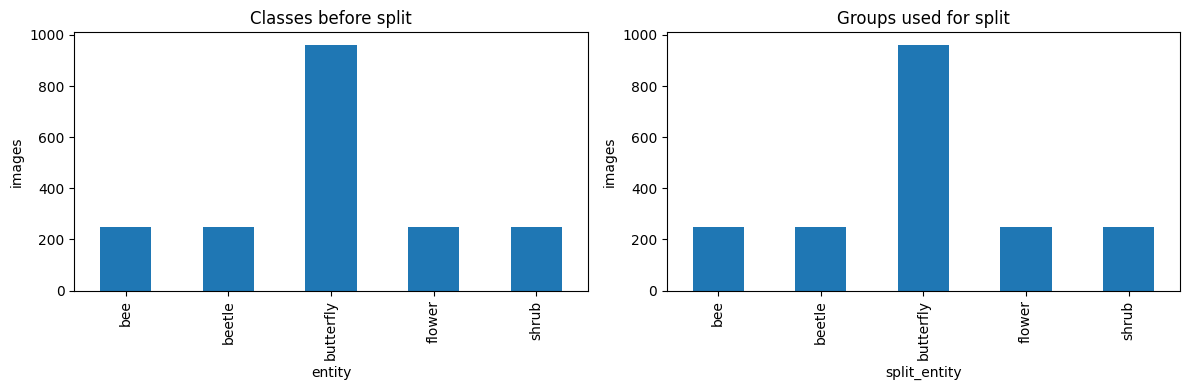

In [3]:
if "dataset_split" in model_df.columns and model_df["dataset_split"].notna().any():
    train_mask = model_df["dataset_split"].eq("train")
    val_mask = model_df["dataset_split"].isin(["val", "valid", "validation", "test"])

    if train_mask.any() and val_mask.any():
        train_df = model_df.loc[train_mask].copy().reset_index(drop=True)
        val_df = model_df.loc[val_mask].copy().reset_index(drop=True)
    else:
        train_df, val_df = train_test_split(
            model_df,
            test_size=VAL_SIZE,
            random_state=RANDOM_STATE,
            stratify=model_df["split_entity"],
        )
        train_df = train_df.reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)
else:
    train_df, val_df = train_test_split(
        model_df,
        test_size=VAL_SIZE,
        random_state=RANDOM_STATE,
        stratify=model_df["split_entity"],
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_df),
        "positives": int(train_df["is_positive"].sum()),
        "negatives": int(train_df["is_negative"].sum()),
    },
    {
        "split": "val",
        "rows": len(val_df),
        "positives": int(val_df["is_positive"].sum()),
        "negatives": int(val_df["is_negative"].sum()),
    },
])
display(split_summary)

display(
    pd.concat(
        {
            "train": train_df["entity"].value_counts().sort_index(),
            "val": val_df["entity"].value_counts().sort_index(),
        },
        axis=1,
    ).fillna(0).astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_df["entity"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Classes before split")
axes[0].set_ylabel("images")
model_df["split_entity"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Groups used for split")
axes[1].set_ylabel("images")
plt.tight_layout()
plt.show()


## Подготовка YOLO-датасета


In [4]:
def image_filename(row) -> str:
    suffix = Path(urlparse(row.image).path).suffix or ".jpg"
    return f"{row.photo_id}{suffix}"


def bbox_to_yolo_line(bbox: dict) -> str:
    x_center = bbox["left"] + bbox["width"] / 2
    y_center = bbox["top"] + bbox["height"] / 2
    return f"0 {x_center:.6f} {y_center:.6f} {bbox['width']:.6f} {bbox['height']:.6f}"


downloads_dir = Path("final_tuning/downloads")
shared_downloads_dirs = [
    downloads_dir,
    Path("4-vlm/downloads"),
    Path("1-scrape/data/downloads"),
]
dataset_dir = Path("final_tuning/dataset")
shutil.rmtree(dataset_dir, ignore_errors=True)
downloads_dir.mkdir(parents=True, exist_ok=True)

full_df = pd.concat([train_df, val_df], ignore_index=True).drop_duplicates(subset=["photo_id"])
local_path_map = {}
image_cache_index = {}
for cache_dir in shared_downloads_dirs:
    if not cache_dir.exists():
        continue
    for image_path in cache_dir.glob("*"):
        if image_path.is_file() and image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}:
            image_cache_index.setdefault(image_path.stem, image_path)
print("indexed cached images:", len(image_cache_index))


def resolve_existing_image(row):
    preferred_path = downloads_dir / image_filename(row)
    if preferred_path.exists():
        return preferred_path

    row_local = getattr(row, "local_image", None)
    if isinstance(row_local, str) and row_local.strip():
        local_candidate = Path(row_local)
        if local_candidate.exists():
            return local_candidate
        repo_candidate = Path("4-vlm") / local_candidate
        if repo_candidate.exists():
            return repo_candidate

    indexed_match = image_cache_index.get(str(row.photo_id))
    if indexed_match and indexed_match.exists():
        return indexed_match

    return preferred_path


missing_images = []
downloaded_images = 0
reused_images = 0
progress = tqdm(full_df.itertuples(index=False), total=len(full_df), desc="prepare images", unit="img")
for row in progress:
    image_path = resolve_existing_image(row)
    if not image_path.exists():
        try:
            response = requests.get(row.image, timeout=120)
            response.raise_for_status()
            target_path = downloads_dir / image_filename(row)
            target_path.write_bytes(response.content)
            image_path = target_path
            downloaded_images += 1
        except Exception:
            missing_images.append(row.photo_id)
            progress.set_postfix(downloaded=downloaded_images, reused=reused_images, missing=len(missing_images))
            continue
    else:
        reused_images += 1
    local_path_map[row.photo_id] = str(image_path)
    progress.set_postfix(downloaded=downloaded_images, reused=reused_images, missing=len(missing_images))

train_df = train_df.loc[train_df["photo_id"].isin(local_path_map)].copy().reset_index(drop=True)
val_df = val_df.loc[val_df["photo_id"].isin(local_path_map)].copy().reset_index(drop=True)
train_df["local_image"] = train_df["photo_id"].map(local_path_map)
val_df["local_image"] = val_df["photo_id"].map(local_path_map)

nonempty_label_counts = {}
for split_name, split_df in [("train", train_df), ("val", val_df)]:
    image_dir = dataset_dir / "images" / split_name
    label_dir = dataset_dir / "labels" / split_name
    image_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)
    nonempty_labels = 0

    for row in split_df.itertuples(index=False):
        src = Path(row.local_image)
        shutil.copy2(src, image_dir / src.name)

        label_path = label_dir / f"{src.stem}.txt"
        if row.is_positive:
            label_path.write_text(bbox_to_yolo_line(row.bbox) + "\n", encoding="utf-8")
            nonempty_labels += 1
        else:
            label_path.write_text("", encoding="utf-8")
    nonempty_label_counts[split_name] = nonempty_labels

data_yaml_path = dataset_dir / "data.yaml"
data_yaml_path.write_text(yaml.safe_dump({
    "path": str(dataset_dir.resolve()),
    "train": "images/train",
    "val": "images/val",
    "names": {0: "butterfly"},
}, sort_keys=False), encoding="utf-8")

print("downloaded images:", downloaded_images)
print("reused images:", reused_images)
print("missing images:", len(missing_images))
if missing_images:
    print("first missing photo_ids:", missing_images[:10])
print("cached images:", len(local_path_map))
print("train images:", len(train_df))
print("val images:", len(val_df))
print("train positive labels:", nonempty_label_counts.get("train", 0))
print("val positive labels:", nonempty_label_counts.get("val", 0))
if nonempty_label_counts.get("train", 0) == 0 or nonempty_label_counts.get("val", 0) == 0:
    raise ValueError("YOLO dataset has zero positive labels in train or val split. Stop and inspect parsing/splits.")
print()
print(data_yaml_path.read_text(encoding="utf-8"))


prepare images:   0%|          | 0/981 [00:00<?, ?img/s]

KeyboardInterrupt: 

## Обучение


In [ ]:
model = YOLO(MODEL_NAME)

try:
    train_results = model.train(
        data=str(data_yaml_path),
        epochs=EPOCHS,
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        project="runs",
        name="yolo_final_tuning",
        exist_ok=True,
        plots=True,
        amp=False,
        patience=PATIENCE,
        workers=0,
    )
    train_device = DEVICE
except RuntimeError as exc:
    if DEVICE == "mps" and "Dimension size must be non-negative" in str(exc):
        print("MPS внутри Ultralytics сломался, повторяем на CPU")
        model = YOLO(MODEL_NAME)
        train_results = model.train(
            data=str(data_yaml_path),
            epochs=EPOCHS,
            imgsz=IMAGE_SIZE,
            batch=BATCH_SIZE,
            device="cpu",
            project="runs",
            name="yolo_final_tuning",
            exist_ok=True,
            plots=True,
            amp=False,
            patience=PATIENCE,
            workers=0,
        )
        train_device = "cpu"
    else:
        raise

run_dir = Path(train_results.save_dir)
print("train_device =", train_device)
print("run_dir =", run_dir)
print("best_weights =", run_dir / "weights" / "best.pt")


Ultralytics 8.4.39 🚀 Python-3.12.7 torch-2.11.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=final_tuning/dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_final_tuning, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=4, perspectiv

/Users/mvsevolod/projects/aiconf-butterflies/.venv/lib/python3.12/site-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/Users/mvsevolod/projects/aiconf-butterflies/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        2/8      4.38G          0      72.87          0          0        640: 100% ━━━━━━━━━━━━ 31/31 1.1s/it 35.1s0.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.2s/it 13.0s2.6s
                   all        182          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/Users/mvsevolod/projects/aiconf-butterflies/.venv/lib/python3.12/site-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/Users/mvsevolod/projects/aiconf-butterflies/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        3/8      4.39G          0      60.71          0          0        640: 100% ━━━━━━━━━━━━ 31/31 1.2s/it 36.8s0.8ss
WARNING ⚠️ NMS time limit 3.600s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 17% ━━────────── 1/6 15.9s/it 4.8s<1:19WARNING ⚠️ NMS time limit 3.600s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 33% ━━━━──────── 2/6 9.6s/it 9.7s<38.4sWARNING ⚠️ NMS time limit 3.600s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 50% ━━━━━━────── 3/6 7.4s/it 14.6s<22.2sWARNING ⚠️ NMS time limit 3.600s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 67% ━━━━━━━━──── 4/6 6.5s/it 19.6s<12.9sWARNING ⚠️ NMS time limit 3.600s exceeded
                 Class     Images  Instances      Box(P          R     

/Users/mvsevolod/projects/aiconf-butterflies/.venv/lib/python3.12/site-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/Users/mvsevolod/projects/aiconf-butterflies/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        4/8      4.47G          0      54.64          0          0        640: 39% ━━━━╸─────── 12/31 3.6s/it 58.4s<1:08s


KeyboardInterrupt: 

## Лоссы и метрики


In [ ]:
results_df = pd.read_csv(run_dir / "results.csv")
results_df.columns = [column.strip() for column in results_df.columns]

loss_columns = [column for column in ["epoch", "train/box_loss", "train/cls_loss", "train/dfl_loss"] if column in results_df.columns]
loss_table = results_df[loss_columns].copy()
for column in loss_columns:
    if column != "epoch":
        loss_table[column] = loss_table[column].round(4)
loss_table


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

loss_plot_columns = [column for column in ["train/box_loss", "train/cls_loss", "train/dfl_loss"] if column in results_df.columns]
if loss_plot_columns:
    results_df.plot(
        x="epoch",
        y=loss_plot_columns,
        ax=axes[0],
        marker="o",
        title="Train loss by epoch",
    )
    axes[0].set_ylabel("loss")
    axes[0].grid(alpha=0.3)
else:
    axes[0].axis("off")
    axes[0].text(0.5, 0.5, "Train loss columns were not found in results.csv", ha="center", va="center")

metric_columns = [
    column
    for column in [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
    ]
    if column in results_df.columns
]

if metric_columns:
    results_df.plot(
        x="epoch",
        y=metric_columns,
        ax=axes[1],
        marker="o",
        title="Validation metrics by epoch",
    )
    axes[1].set_ylabel("score")
    axes[1].grid(alpha=0.3)
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "Validation metrics were not found in results.csv", ha="center", va="center")

plt.tight_layout()
plt.show()

last_row = results_df.iloc[-1]
final_summary = pd.DataFrame([
    {"metric": "train_box_loss", "value": float(last_row.get("train/box_loss", np.nan))},
    {"metric": "train_cls_loss", "value": float(last_row.get("train/cls_loss", np.nan))},
    {"metric": "train_dfl_loss", "value": float(last_row.get("train/dfl_loss", np.nan))},
    {"metric": "precision", "value": float(last_row.get("metrics/precision(B)", np.nan))},
    {"metric": "recall", "value": float(last_row.get("metrics/recall(B)", np.nan))},
    {"metric": "mAP50", "value": float(last_row.get("metrics/mAP50(B)", np.nan))},
    {"metric": "mAP50_95", "value": float(last_row.get("metrics/mAP50-95(B)", np.nan))},
])
final_summary["value"] = final_summary["value"].round(4)
final_summary


## Вывод

В этой версии ноутбук уже адаптирован именно под `qwen-eval`:

1. берём bbox из `gt_boxes`;
2. если в датасете уже есть `dataset_split`, используем его;
3. сначала ищем картинки в `4-vlm/downloads` и только потом пытаемся скачать заново;
4. смотрим таблицу лоссов и итоговые графики обучения.
